In [1]:

import multiprocessing

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
import pytensor.tensor as pt
from scipy.optimize import curve_fit
from scipy.stats import norm
from matplotlib.ticker import MultipleLocator


/home/ritaferi/pymc-env/lib/python3.12/site-packages/arviz/__init__.py:50: FutureWarning: 
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/latest/user_guide/migration_guide.html
  warn(


# FUNCTIONS

In [60]:

def add_peak(ax, x, text, y_text, y_line_top=60):
    """
    ax       : axis
    x        : posizione del picco (keV)
    text     : label da scrivere
    y_text   : posizione testo
    y_line_top : altezza linea verticale
    """

    # linea verticale tratteggiata
    ax.vlines(
        x,
        0,
        y_line_top,
        ls='--',
        color='black',
        alpha=0.75
    )

    # annotazione (ruotata come nel tuo esempio)
    ax.annotate(
        text,
        xy=(x - 2, y_text),
        rotation=90,
        fontsize=11
    )

In [3]:


# ============================================================
# BUILD TOTAL DATASET
# ============================================================
def build_total_spectrum(files_config, bins):
    all_histograms = []
    total_time = 0

    for key, cfg in files_config.items():
        E, spectrum = load_spectrum(
            cfg["path"],
            cfg["calibration"],
            ENERGY_RANGE,
        )

        E_centers, counts = make_histogram(E, spectrum, bins)

        all_histograms.append(counts)
        total_time += cfg["time"]

    total_counts = np.sum(all_histograms, axis=0)

    return E_centers, total_counts, total_time

In [4]:

# ============================================================
# GAUSSIAN MODEL
# ============================================================
def gaussian_plus_bg(E, mu, sigma, area, m, background, ):


    gaussian = (
        area
        / (sigma * np.sqrt(2 * np.pi))
        * np.exp(-0.5 * ((E - mu) / sigma) ** 2)
    )

    return gaussian + background + m*E


In [5]:
# ============================================================
# HISTOGRAMMING
# ============================================================
def make_histogram(E, spectrum, bins):
    counts, edges = np.histogram(E, bins=bins, weights=spectrum)
    centers = 0.5 * (edges[1:] + edges[:-1])

    return centers, counts



In [6]:

# ============================================================
# DATA LOADING
# ============================================================
def load_spectrum(file_path, calibration, energy_range=(0, 3000)):
    """
    Load raw spectrum and convert channels to energy.
    """

    data = pd.read_csv(file_path, header=None)
    spectrum = data[0].to_numpy(dtype=np.float64)

    channels = np.arange(len(spectrum))

    E = (
        channels * calibration["a"]
        + calibration["b"]
        + calibration["c"] * channels**2
    )

    mask = (E >= energy_range[0]) & (E <= energy_range[1])

    return E[mask], spectrum[mask]

In [7]:
# ============================================================
# ENERGY RESOLUTION
# ============================================================
def sigma_fun(E):
    """
    Detector energy resolution model.
    Returns sigma in keV.
    """
    A = 3.68436e1
    B = 1.72714e4

    return (E * np.sqrt(A / E + B / E**2)) / 2.355 / 100
    


# Plot setup

In [8]:
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 14,
    "axes.labelsize": 14,
    "axes.titlesize": 14,
    "legend.fontsize": 14,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "figure.figsize": (5.8, 3.6),  # tipico per colonna singola
    "lines.linewidth": 1.2,
    "axes.linewidth": 0.8,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
})

# DATI

In [9]:
# ============================================================
# CONFIGURATION
# ============================================================
FILES = {
    "50d": {
        "path": "csv-files/zro2_white&green_ 50_days.csv",
        "time": 4279386,
        "calibration": {
            "a": 0.357304,
            "b": -0.295444,
            "c": 1.352297e-9,
        },
    },
    "30d": {
        "path": "csv-files/new_data.csv",
        "time": 2827661,
        "calibration": {
            "a": 0.4142675,
            "b": 2.78,
            "c": 8.4771e-7,
        },
    },
}




In [10]:
ENERGY_RANGE = (0, 3000)


SIGNAL = {
    "mu": 778.2,
    "roi": (748, 810),
}

SAMPLING_CONFIG = {
    "draws": 2000,
    "tune": 2000,
    "chains": 4,
    "target_accept": 0.95,
}


In [11]:
# ============================================================
# MAIN DATA PREPARATION
# ============================================================
BIN_WIDTH =0.4
BINS = np.arange(ENERGY_RANGE[0], ENERGY_RANGE[1], BIN_WIDTH)

E_tot, Ntot, t_tot = build_total_spectrum(FILES, BINS)

print(
    f"Total counts = {np.sum(Ntot):.0f} "
    f"in {t_tot / (60 * 60 * 24):.1f} days"
)


Total counts = 18324 in 82.3 days


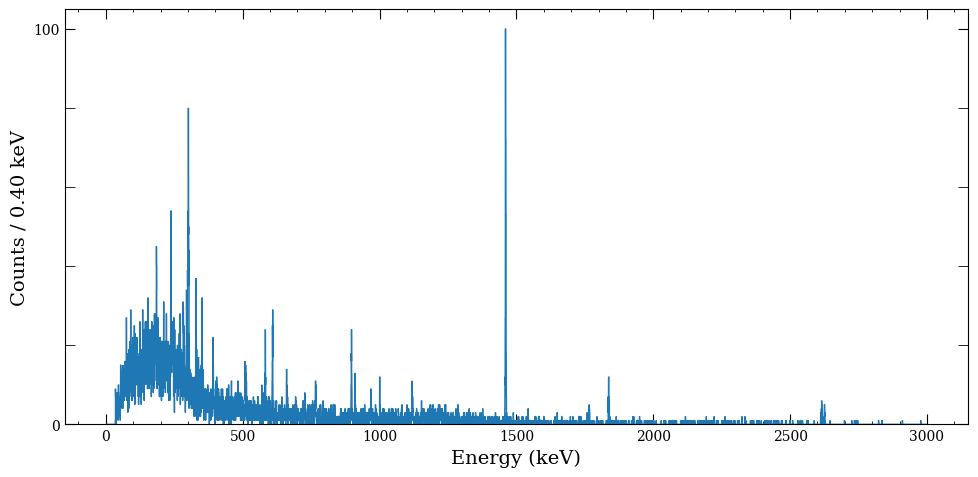

In [12]:

plt.figure(figsize=(10,5))
ax = plt.gca()


dx_major = 500
dx_minor = 100

ax.xaxis.set_major_locator(MultipleLocator(dx_major))
ax.xaxis.set_minor_locator(MultipleLocator(dx_minor))
dy_major = 100
dy_minor = 20

ax.yaxis.set_major_locator(MultipleLocator(dy_major))
ax.yaxis.set_minor_locator(MultipleLocator(dy_minor))

ax.tick_params(axis='x', which='major', length=7, labelsize=10)
#ax.tick_params(axis='x', which='minor', length=4)

ax.tick_params(axis='y', which='major', length=7, labelsize=10)
ax.tick_params(axis='y', which='minor', length=7)

# Bin width
db =0.4
bins_common = np.arange(0,3000+db,db)


c, bc, _ = plt.hist(E_tot, bins = bins_common, 
             weights = Ntot, 
             histtype='step',
            )


db_plot = (bc[1]-bc[0]) 


plt.xlabel('Energy (keV)')
plt.ylabel(rf'Counts / {db_plot:.2f} keV')
#plt.yscale('log')
#plt.grid(alpha=0.15)
#ax.grid(which='major', linestyle='-', alpha=0.15)
#ax.grid(which='minor', linestyle='--', alpha=0.15)
plt.tight_layout()
#plt.legend(fontsize=15)

plt.savefig("spectrum_50_days.png")
plt.show()


# Background

# PYMC

In [45]:
BACKGROUND_PEAKS = {
    "95Zr": {"E": 756.73, "N": 6.5},
    "214Bi": {"E": 768.4, "N": 5.11},
    "95Nb": {"E": 765.8, "N": 18},
    "214Pb+212Bi": {"E": 785.95, "N": 3.33},
    "228Ac": {"E": 794.947, "N": 3.55},
}

In [46]:
# ============================================================
# ROI SELECTION
# ============================================================
roi_mask = (
    (E_tot > SIGNAL["roi"][0])
    & (E_tot < SIGNAL["roi"][1])
)

E_roi = E_tot[roi_mask]
counts_roi = Ntot[roi_mask]

sigma_common = sigma_fun(E_roi.mean())


background_names = list(BACKGROUND_PEAKS.keys())

background_energies = np.array([
    BACKGROUND_PEAKS[name]["E"] for name in background_names
])

background_intensities = np.array([
    BACKGROUND_PEAKS[name]["N"] for name in background_names
])


In [47]:
mu_signal = SIGNAL["mu"]
sigma_signal = sigma_fun(mu_signal)

PDF_signal = norm.pdf(E_roi, mu_signal, sigma_common)

PDF_bg = np.array(
    [
        norm.pdf(E_roi, mu, sigma_common)
        for mu in background_energies
    ]
)

In [48]:
with pm.Model() as model:

    # ------------------------
    # Background priors
    # ------------------------
    A_bg = []
    mu_bg = []

    for i, peak_name in enumerate(background_names):

        fit = BACKGROUND_PEAKS[peak_name]

        A = pm.TruncatedNormal(
            f"A_{peak_name}",
            mu=fit["N"],
            sigma=0.20 * fit["N"], 
            lower=0,
        )

        mu = pm.Normal(
            f"mu_{peak_name}",
            mu=fit["E"],
            sigma=0.5
        )

        A_bg.append(A)
        mu_bg.append(mu)

    A_bg = pt.stack(A_bg)
    mu_bg = pt.stack(mu_bg)

    # ------------------------
    # Signal prior
    # ------------------------
    A_signal = pm.HalfNormal(
        "A_signal",
        sigma=500,
    )

    # ------------------------
    # Flat background
    # ------------------------
    Q = pm.HalfNormal(
        "Q",
        sigma=500,
    )

    # ------------------------
    # Expected counts
    # ------------------------
    lambda_E = (
        Q
        + pt.sum(A_bg[:, None] * PDF_bg, axis=0)
        + A_signal * PDF_signal
    )

    lambda_E = pt.clip(lambda_E, 1e-9, np.inf)

    # ------------------------
    # Likelihood
    # ------------------------
    pm.Poisson(
        "counts_obs",
        mu=lambda_E,
        observed=counts_roi,
    )

    # ------------------------
    # Sampling
    # ------------------------
    trace = pm.sample(
        draws=SAMPLING_CONFIG["draws"],
        tune=SAMPLING_CONFIG["tune"],
        chains=SAMPLING_CONFIG["chains"],
        cores=min(4, multiprocessing.cpu_count()),
        target_accept=SAMPLING_CONFIG["target_accept"],
        init="jitter+adapt_diag",
        return_inferencedata=True,
        progressbar=True,
    )

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [A_95Zr, mu_95Zr, A_214Bi, mu_214Bi, A_95Nb, mu_95Nb, A_214Pb+212Bi, mu_214Pb+212Bi, A_228Ac, mu_228Ac, A_signal, Q]


Output()

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 3 seconds.


In [49]:
# ============================================================
# SUMMARY
# ============================================================
summary = az.summary(trace, round_to=4)
print(summary)


                    mean      sd    hdi_3%   hdi_97%  mcse_mean  mcse_sd  \
mu_95Zr         756.7328  0.4882  755.8337  757.6878     0.0053   0.0051   
mu_214Bi        768.3961  0.5105  767.4555  769.3697     0.0054   0.0059   
mu_95Nb         765.8012  0.4985  764.8367  766.7053     0.0054   0.0056   
mu_214Pb+212Bi  785.9527  0.4923  785.0212  786.8560     0.0056   0.0051   
mu_228Ac        794.9288  0.4994  794.0023  795.8930     0.0055   0.0055   
A_95Zr            6.8263  1.1163    4.8594    8.9910     0.0115   0.0124   
A_214Bi           4.4997  0.9317    2.8370    6.3188     0.0099   0.0104   
A_95Nb           16.7234  2.3704   12.2814   21.1304     0.0242   0.0275   
A_214Pb+212Bi     2.9124  0.6332    1.7955    4.1800     0.0075   0.0081   
A_228Ac           3.6810  0.6634    2.4112    4.8954     0.0075   0.0082   
A_signal          4.0729  1.9458    0.5275    7.5776     0.0238   0.0233   
Q                 1.3735  0.1055    1.1768    1.5692     0.0011   0.0011   

           

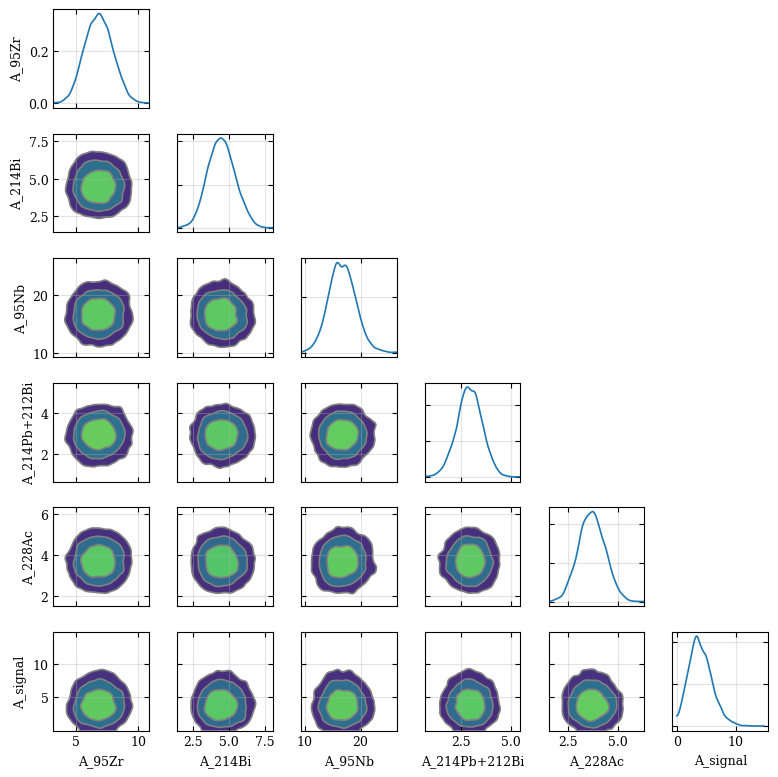

In [50]:

# ============================================================
# CORRELATION PLOTS
# ============================================================
A_vars = [v for v in trace.posterior.data_vars if v.startswith("A_")]

axes = az.plot_pair(
    trace,
    var_names=A_vars,
    kind="kde",
    marginals=True,
    figsize=(8, 8),
    textsize=9,
)

for ax in axes.flatten():
    ax.grid(alpha=0.35)

plt.tight_layout()
plt.show()


In [51]:


# ============================================================
# POSTERIOR OF SIGNAL
# ============================================================
signal_samples = trace.posterior["A_signal"].values.flatten()

N_signal_90 = np.percentile(signal_samples, 90)
N_signal_95 = np.percentile(signal_samples, 95)

print()
print("=" * 60)
print(f"90% upper limit on signal counts : {N_signal_90:.3f}")
print(f"95% upper limit on signal counts : {N_signal_95:.3f}")
print("=" * 60)


90% upper limit on signal counts : 6.648
95% upper limit on signal counts : 7.529


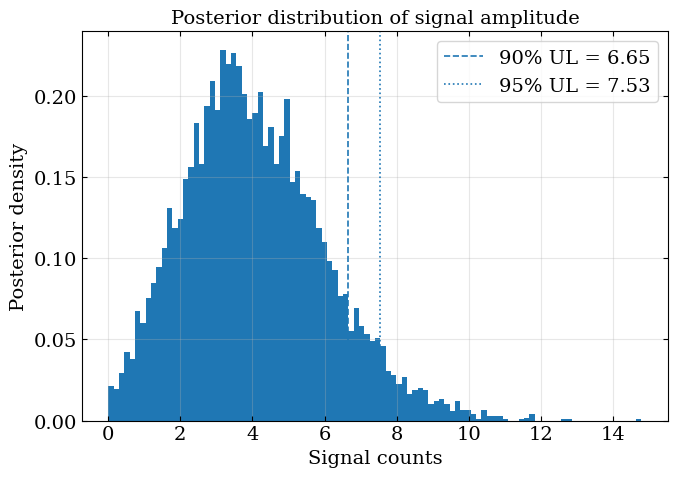

In [52]:
# ============================================================
# SIGNAL POSTERIOR PLOT
# ============================================================
plt.figure(figsize=(7, 5))

plt.hist(signal_samples, bins=100, density=True)

plt.axvline(
    N_signal_90,
    linestyle="--",
    label=f"90% UL = {N_signal_90:.2f}",
)

plt.axvline(
    N_signal_95,
    linestyle=":",
    label=f"95% UL = {N_signal_95:.2f}",
)

plt.xlabel("Signal counts")
plt.ylabel("Posterior density")
plt.title("Posterior distribution of signal amplitude")
plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()



In [53]:
posterior_means = {name: trace.posterior[name].mean().values for name in trace.posterior.data_vars}

print("Ampiezze medie dei picchi:")
for name, val in posterior_means.items():
    print(f"{name}: {val:.2f}")

Ampiezze medie dei picchi:
mu_95Zr: 756.73
mu_214Bi: 768.40
mu_95Nb: 765.80
mu_214Pb+212Bi: 785.95
mu_228Ac: 794.93
A_95Zr: 6.83
A_214Bi: 4.50
A_95Nb: 16.72
A_214Pb+212Bi: 2.91
A_228Ac: 3.68
A_signal: 4.07
Q: 1.37


In [54]:
background_names = list(BACKGROUND_PEAKS.keys())

background_energies = np.array([
    BACKGROUND_PEAKS[name]["E"] for name in background_names
])

background_sigmas = sigma_fun(background_energies)


In [55]:
# ============================================================
# POSTERIOR EXTRACTION
# ============================================================
idata = trace
posterior = idata.posterior

sigma_common = sigma_fun(E_roi.mean())

Q_s        = posterior["Q"].values.flatten()
A_signal_s = posterior["A_signal"].values.flatten()

A_bg_s = {
    name: posterior[f"A_{name}"].values.flatten()
    for name in background_names
}

# ============================================================
# GRID FINE PER CURVE LISCE
# ============================================================
E_fine = np.linspace(E_roi.min(), E_roi.max(), 3000)

# ============================================================
# INTERPOLAZIONE PDF
# ============================================================
from scipy.interpolate import interp1d

interp_signal = interp1d(
    E_roi,
    PDF_signal,
    kind='cubic',
    bounds_error=False,
    fill_value=0
)

PDF_signal_fine = interp_signal(E_fine)

PDF_bg_fine = []

for j in range(len(background_names)):

    interp_bg = interp1d(
        E_roi,
        PDF_bg[j],
        kind='cubic',
        bounds_error=False,
        fill_value=0
    )

    PDF_bg_fine.append(interp_bg(E_fine))

PDF_bg_fine = np.array(PDF_bg_fine)

# ============================================================
# COSTRUZIONE λ(E) SUI BIN ORIGINALI
# (serve per residui/statistiche)
# ============================================================
lambda_samples = []
lambda_back = []

for i in range(len(Q_s)):

    lam = Q_s[i] * np.ones_like(E_roi)
    lam_bkg = Q_s[i] * np.ones_like(E_roi)

    for j, name in enumerate(background_names):

        lam += A_bg_s[name][i] * PDF_bg[j]
        lam_bkg += A_bg_s[name][i] * PDF_bg[j]

    lam += A_signal_s[i] * PDF_signal

    lambda_samples.append(lam)
    lambda_back.append(lam_bkg)

lambda_samples = np.array(lambda_samples)
lambda_back    = np.array(lambda_back)

# ============================================================
# STATISTICHE POSTERIORI
# ============================================================
lambda_mean = np.mean(lambda_samples, axis=0)

lambda_low = np.percentile(
    lambda_back,
    5,
    axis=0
)

lambda_high = np.percentile(
    lambda_back,
    95,
    axis=0
)

# incertezza del modello
model_std = np.std(lambda_samples, axis=0)

# ============================================================
# MEDIA POSTERIORE PARAMETRI
# ============================================================
posterior_means = {
    var: posterior[var].values.mean()
    for var in posterior.data_vars
}

# ============================================================
# COSTRUZIONE MODELLO LISCIO
# ============================================================
lambda_pred_bkg_fine = (
    posterior_means['Q']
    * np.ones_like(E_fine)
)

for j, name in enumerate(background_names):

    lambda_pred_bkg_fine += (
        posterior_means[f"A_{name}"]
        * PDF_bg_fine[j]
    )

# ============================================================
# LIMITE 90% SUL SEGNALE
# ============================================================
N_signal_90 = np.percentile(A_signal_s, 90)

lambda_pred_fine = (
    lambda_pred_bkg_fine
    + N_signal_90 * PDF_signal_fine
)

# ============================================================
# RESIDUI NORMALIZZATI
# ============================================================
total_sigma = np.sqrt(
    lambda_mean + model_std**2
)

residuals = (
    counts_roi - lambda_mean
) / total_sigma

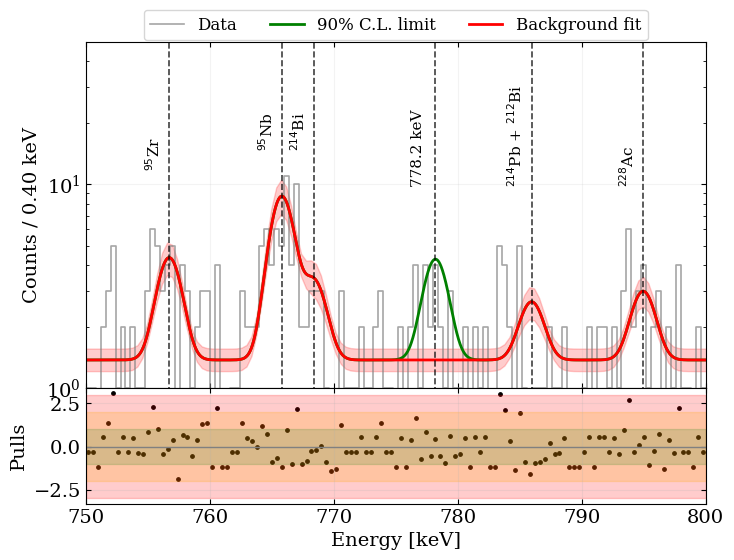

In [66]:


# ============================================================
# FIGURA
# ============================================================
fig, (ax1, ax2) = plt.subplots(
    2,
    1,
    sharex=True,
    gridspec_kw={"height_ratios": [3, 1]},
    figsize=(8, 6)
)

# ============================================================
# PLOT SUPERIORE
# ============================================================
ax1.step(
    E_roi,
    counts_roi,
    where='mid',
    color='grey',
    alpha=0.7,
    label='Data'
)

# modello totale
ax1.plot(
    E_fine,
    lambda_pred_fine,
    color='green',
    lw=2,
    label='90% C.L. limit'
)

# background
ax1.plot(
    E_fine,
    lambda_pred_bkg_fine,
    color='red',
    lw=2,
    label='Background fit'
)

# banda credibile background
ax1.fill_between(
    E_roi,
    lambda_low,
    lambda_high,
    color='red',
    alpha=0.2
)

ax1.set_yscale('log')
ax1.set_ylim(1, 50)
ax1.set_xlim(750, 800)

ax1.set_ylabel(
    f"Counts / {E_roi[1]-E_roi[0]:.2f} keV"
)


add_peak(ax1, 778.2, r"778.2 keV", 10)
add_peak(ax1, 756.73, r"$^{95}$Zr", 12)
add_peak(ax1, 765.8, r"$^{95}$Nb", 15)
add_peak(ax1, 768.4, r"$^{214}$Bi", 15)
add_peak(ax1, 785.95, r"$^{214}$Pb + $^{212}$Bi", 10)
add_peak(ax1, 794.947, r"$^{228}$Ac", 10)





ax1.grid(alpha=0.15)

ax1.legend(
    loc="lower center",
    bbox_to_anchor=(0.5, 0.98),
    ncol=3,
    fontsize=12
)

# ============================================================
# RESIDUI
# ============================================================
ax2.scatter(
    E_roi,
    residuals,
    s=6,
    color='black'
)

ax2.axhspan(
    -3,
    3,
    color='red',
    alpha=0.20
)

ax2.axhspan(
    -2,
    2,
    color='orange',
    alpha=0.20
)

ax2.axhspan(
    -1,
    1,
    color='green',
    alpha=0.15
)

ax2.axhline(
    0,
    color='gray',
    lw=1
)

ax2.set_xlabel("Energy [keV]")
ax2.set_ylabel("Pulls")

ax2.grid(alpha=0.2)

# ============================================================
# LAYOUT
# ============================================================
plt.subplots_adjust(hspace=0)

plt.show()

# Half life

In [68]:
# Dati campione
m_sample = 551.3        # massa ZrO2 in grammi
Mr_sample = 123.22      # massa molare ZrO2 [g/mol]
N_A = 6.022e23          # numero di Avogadro
eff_96Zr = 0.024131    # efficienza di rivelazione
i_a_96Zr = 0.0280     # abbondanza isotopica
t_live =    t_tot/(60*60*24*365)             # 90 giorni in anni


# Numero di nuclei 96Zr nel campione
N_nuclei = (m_sample * i_a_96Zr / Mr_sample) * N_A


In [69]:
# Posterior del numero di eventi segnale
signal_samples = trace.posterior['A_signal'].values.flatten()
signal_samples

array([5.19808687, 4.06910598, 6.74191179, ..., 3.5414351 , 5.2233776 ,
       4.40249731], shape=(8000,))

In [71]:

percentile = 90

T_half_limit = (np.log(2) * N_nuclei * eff_96Zr * t_live) / np.percentile(signal_samples, percentile)
print(f"T1/2 > {T_half_limit:.2e} yrs at {percentile}%")

T1/2 > 4.28e+19 yrs at 90%
